<a href="https://colab.research.google.com/github/dexter19-Aero/github-basics/blob/Projects/Hybrid_Aircraft_Battery_AI_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Based Hybrid Aircraft Battery Health & Power Optimization System

This project simulates a hybrid-electric aircraft power system and uses AI
to predict battery health and optimize power distribution.

## Team Name: AeroNex
## Problem Statement: Hybrid and Electic Flight Systems
## Tools Used:
- Python
- NumPy
- Pandas
- Scikit-learn
- Matplotlib

## System Initialization

In [ ]:
# Hybrid Aircraft System Parameters

battery_capacity = 500  # kWh
max_temperature = 80  # °C
max_voltage = 800  # Volts
max_engine_power = 1000  # kW

print("System Initialized Successfully")

System Initialized Successfully


## Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## Flight Phase Simulation

In [ ]:
# Simulate 1000 time steps (~one full flight)
time_steps = 1000
time = np.arange(time_steps)

# Flight phases
flight_phase = []

for t in time:
    if t < 200:
        flight_phase.append("Takeoff")
    elif t < 800:
        flight_phase.append("Cruise")
    else:
        flight_phase.append("Landing")

## Power Demand Simulation

In [ ]:
power_demand = []

for phase in flight_phase:
    if phase == "Takeoff":
        power_demand.append(np.random.normal(900, 50))
    elif phase == "Cruise":
        power_demand.append(np.random.normal(600, 40))
    else:
        power_demand.append(np.random.normal(300, 30))

## Battery Performance Modeling

In [ ]:
soc = 100  # starting at 100%
battery_soc = []
battery_temp = []
battery_voltage = []
engine_power = []

for demand in power_demand:

    battery_share = np.random.uniform(0.8, 0.9)
    battery_power = demand * battery_share
    engine = demand - battery_power

    soc -= battery_power * 0.0005
    temperature = 30 + (battery_power * 0.02) + np.random.normal(0, 2)
    voltage = 800 - (100 - soc) * 2 + np.random.normal(0, 5)

    battery_soc.append(max(soc, 0))
    battery_temp.append(temperature)
    battery_voltage.append(voltage)
    engine_power.append(engine)

## Battery Health Classification Logic

In [ ]:
health_status = []

for temp, soc_val in zip(battery_temp, battery_soc):
    if temp > 75 or soc_val < 20:
        health_status.append("Critical")
    elif temp > 65 or soc_val < 40:
        health_status.append("Warning")
    else:
        health_status.append("Normal")

## Dataset Creation

In [ ]:
data = pd.DataFrame({
    "Time": time,
    "Flight_Phase": flight_phase,
    "Power_Demand_kW": power_demand,
    "Battery_SOC_%": battery_soc,
    "Battery_Temperature_C": battery_temp,
    "Battery_Voltage_V": battery_voltage,
    "Engine_Power_kW": engine_power,
    "Health_Status": health_status
})

data.head()

,Time,Flight_Phase,Power_Demand_kW,Battery_SOC_%,Battery_Temperature_C,Battery_Voltage_V,Engine_Power_kW,Health_Status
0,0,Takeoff,924.835708,99.622321,45.658180,795.251915,169.477754,Normal
1,1,Takeoff,893.086785,99.233539,45.670538,795.232394,115.522943,Normal
2,2,Takeoff,932.384427,98.827529,47.026911,801.062284,120.365187,Normal
3,3,Takeoff,976.151493,98.397938,49.282745,794.119701,116.969492,Normal
4,4,Takeoff,888.292331,98.039063,44.584075,800.828854,170.541926,Normal


In [ ]:
data.to_csv("hybrid_aircraft_data.csv", index=False)

## Data Visualization

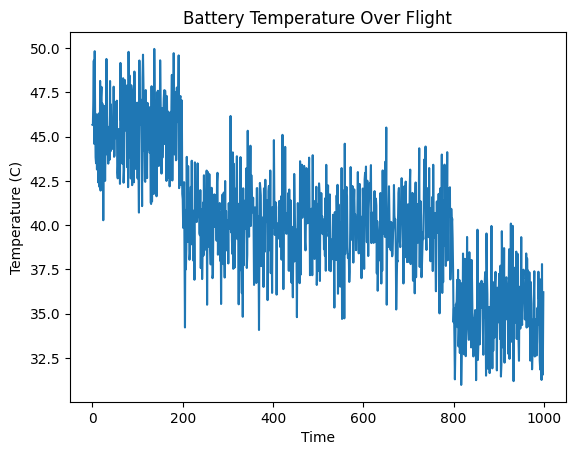

In [ ]:
plt.figure()
plt.plot(data["Battery_Temperature_C"])
plt.title("Battery Temperature Over Flight")
plt.xlabel("Time")
plt.ylabel("Temperature (C)")
plt.show()